# Notebook 01 : Exploration des Données (EDA)

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuration pour de belles visualisations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

In [32]:
# Charge le fichier CSV
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"📊 Dataset chargé : {df.shape[0]} lignes (clients) × {df.shape[1]} colonnes (variables)")
print("\n" + "="*80)

📊 Dataset chargé : 7043 lignes (clients) × 21 colonnes (variables)



APERÇU INITIAL DES DONNÉES

In [ ]:
# Remplacer les virgules par des points (format européen)
df['TotalCharges'] = df['TotalCharges'].str.replace(',', '.', regex=False)

# Supprimer les espaces et caractères non numériques
df['TotalCharges'] = df['TotalCharges'].str.replace(r'[^\d.]', '', regex=True)

# Convertir en float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [34]:
print("\n🔍 APERÇU DES 5 PREMIÈRES LIGNES :")
print(df.head())


🔍 APERÇU DES 5 PREMIÈRES LIGNES :
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV S

In [35]:
print("\n📋 INFORMATIONS SUR LES COLONNES :")
print(df.info())


📋 INFORMATIONS SUR LES COLONNES :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperle

In [36]:
print("\n📈 STATISTIQUES DESCRIPTIVES (variables numériques) :")
print(df.describe())


📈 STATISTIQUES DESCRIPTIVES (variables numériques) :
       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7032.000000
mean        0.162147    32.371149       64.761692   2283.300441
std         0.368612    24.559481       30.090047   2266.771362
min         0.000000     0.000000       18.250000     18.800000
25%         0.000000     9.000000       35.500000    401.450000
50%         0.000000    29.000000       70.350000   1397.475000
75%         0.000000    55.000000       89.850000   3794.737500
max         1.000000    72.000000      118.750000   8684.800000


In [37]:
print("\n📊 TYPES DE DONNÉES :")
print(df.dtypes.value_counts())


📊 TYPES DE DONNÉES :
object     17
int64       2
float64     2
Name: count, dtype: int64


ANALYSE DE LA VARIABLE CIBLE (CHURN)

In [38]:
print("\n🎯 ANALYSE DE LA VARIABLE CIBLE : CHURN")
print("="*80)

# Distribution du churn
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("\n📊 Distribution du Churn :")
print(f"  - No (clients restés)  : {churn_counts['No']:,} ({churn_pct['No']:.2f}%)")
print(f"  - Yes (clients partis) : {churn_counts['Yes']:,} ({churn_pct['Yes']:.2f}%)")



🎯 ANALYSE DE LA VARIABLE CIBLE : CHURN

📊 Distribution du Churn :
  - No (clients restés)  : 5,174 (73.46%)
  - Yes (clients partis) : 1,869 (26.54%)


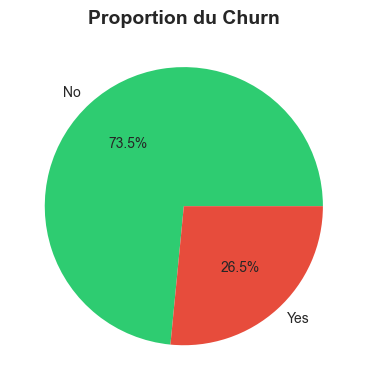

In [53]:
# Visualisation
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

# Graphique circulaire : Pourcentage
churn_pct.plot(kind='pie', autopct='%1.1f%%', ax=ax, colors=['#2ecc71', '#e74c3c'])
ax.set_title('Proportion du Churn', fontsize=14, fontweight='bold')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

In [40]:
print("\n💡 INSIGHT : Le dataset est-il déséquilibré ?")
if churn_pct['Yes'] < 30:
    print(f"   ⚠️ OUI ! Seulement {churn_pct['Yes']:.1f}% de churn.")
else:
    print(f"   ✅ Non, {churn_pct['Yes']:.1f}% de churn est raisonnable.")


💡 INSIGHT : Le dataset est-il déséquilibré ?
   ⚠️ OUI ! Seulement 26.5% de churn.


DÉTECTION DES VALEURS MANQUANTES

In [41]:
print("\n🔍 DÉTECTION DES VALEURS MANQUANTES")
print("="*80)

# Compter les valeurs manquantes par colonne
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Colonne': missing.index,
    'Valeurs manquantes': missing.values,
    'Pourcentage': missing_pct.values
})
missing_df = missing_df[missing_df['Valeurs manquantes'] > 0].sort_values('Valeurs manquantes', ascending=False)
missing_df



🔍 DÉTECTION DES VALEURS MANQUANTES


,Colonne,Valeurs manquantes,Pourcentage
19,TotalCharges,11,0.156183


In [42]:
print("\n💡 Ces valeurs manquantes correspondent aux clients dont la tenure(l'ancienneté) est nulle(0).")
print("\n Les lignes correspondantes seront donc supprimées.")


💡 Ces valeurs manquantes correspondent aux clients dont la tenure(l'ancienneté) est nulle(0).

 Les lignes correspondantes seront donc supprimées.


In [45]:
df= df.dropna(subset=['TotalCharges'])
print("\nAprès suppression des NA dans la colonne TotalCharges:")
print(df.head())


Après suppression des NA dans la colonne TotalCharges:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  Tech

ANALYSE DES VARIABLES NUMÉRIQUES

In [46]:
print("\n📊 ANALYSE DES VARIABLES NUMÉRIQUES")
print("="*80)

# Identifier les colonnes numériques
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Retirer customerID s'il existe
numeric_cols = [col for col in numeric_cols if col != 'customerID']

print(f"\nVariables numériques : {numeric_cols}")


📊 ANALYSE DES VARIABLES NUMÉRIQUES

Variables numériques : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


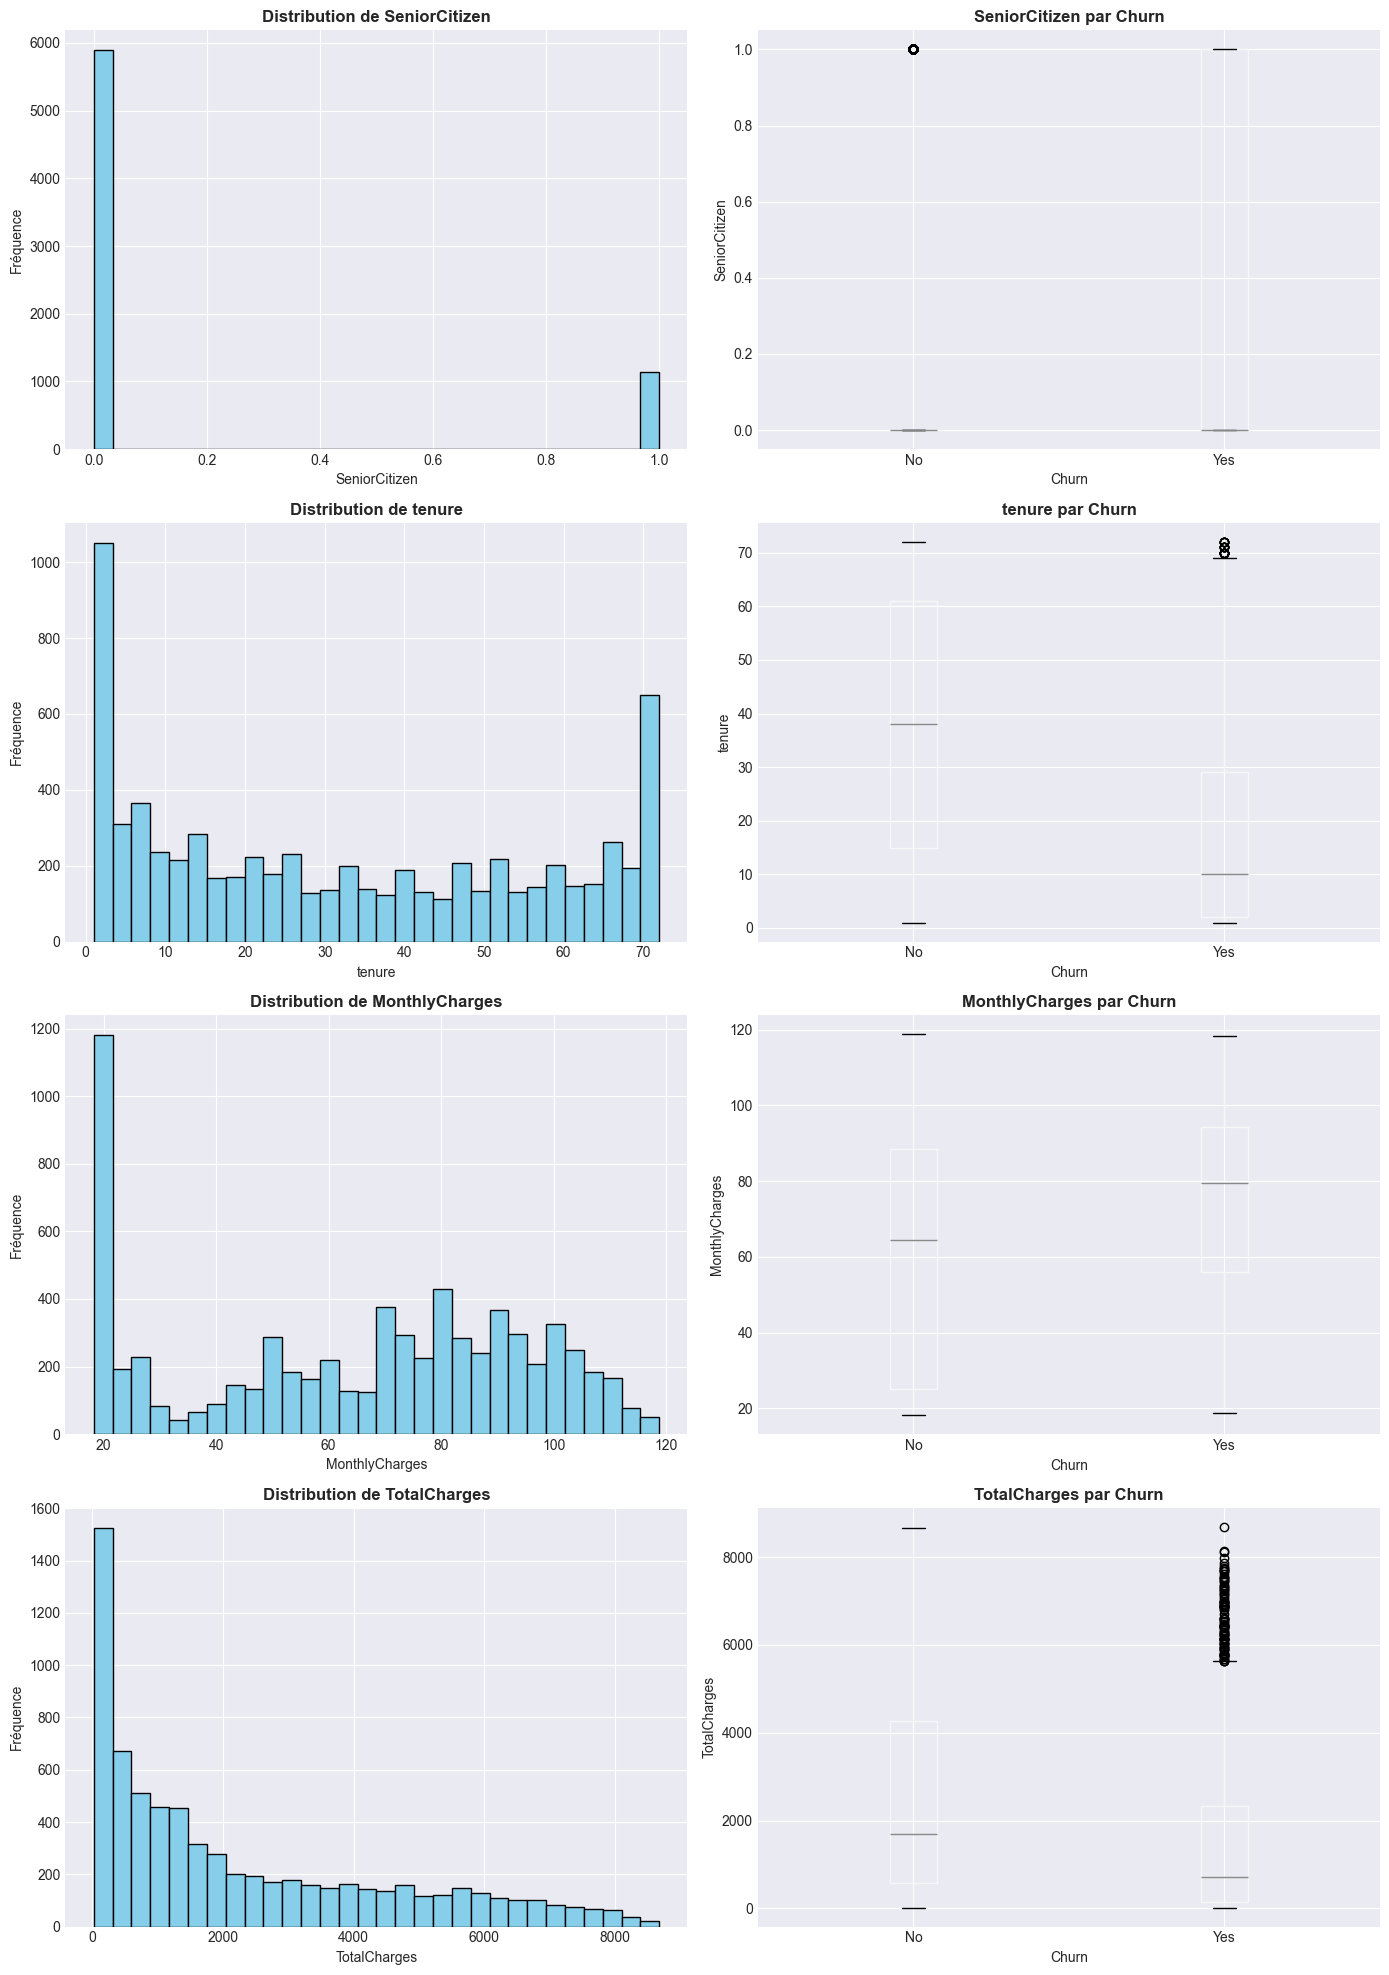

In [ ]:
# Distributions des variables numériques
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, 5*len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    # Histogramme
    axes[i, 0].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    axes[i, 0].set_title(f'Distribution de {col}', fontweight='bold')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Fréquence')
    
    # Boxplot par Churn
    df.boxplot(column=col, by='Churn', ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} par Churn', fontweight='bold')
    axes[i, 1].set_xlabel('Churn')
    axes[i, 1].set_ylabel(col)

plt.suptitle('')  # Enlever le titre auto-généré
plt.tight_layout()
plt.show()

In [54]:
# Statistiques par groupe (Churn = Yes vs No)
print("\n📈 STATISTIQUES PAR GROUPE (Churn Yes vs No) :")
for col in numeric_cols:
    print(f"\n{col}:")
    print(df.groupby('Churn')[col].describe()[['mean', '50%', 'std']])



📈 STATISTIQUES PAR GROUPE (Churn Yes vs No) :

SeniorCitizen:
           mean  50%       std
Churn                         
No     0.128995  0.0  0.335227
Yes    0.254682  0.0  0.435799

tenure:
            mean   50%        std
Churn                            
No     37.650010  38.0  24.076940
Yes    17.979133  10.0  19.531123

MonthlyCharges:
            mean    50%        std
Churn                             
No     61.307408  64.45  31.094557
Yes    74.441332  79.65  24.666053

TotalCharges:
              mean      50%          std
Churn                                   
No     2555.344141  1683.60  2329.456984
Yes    1531.796094   703.55  1890.822994


ANALYSE DES VARIABLES CATÉGORIELLES

In [55]:
print("\n📊 ANALYSE DES VARIABLES CATÉGORIELLES")
print("="*80)

# Identifier les colonnes catégorielles
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('Churn')  # On enlève la variable cible
if 'customerID' in categorical_cols:
    categorical_cols.remove('customerID')

print(f"\nVariables catégorielles : {categorical_cols}")



📊 ANALYSE DES VARIABLES CATÉGORIELLES

Variables catégorielles : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


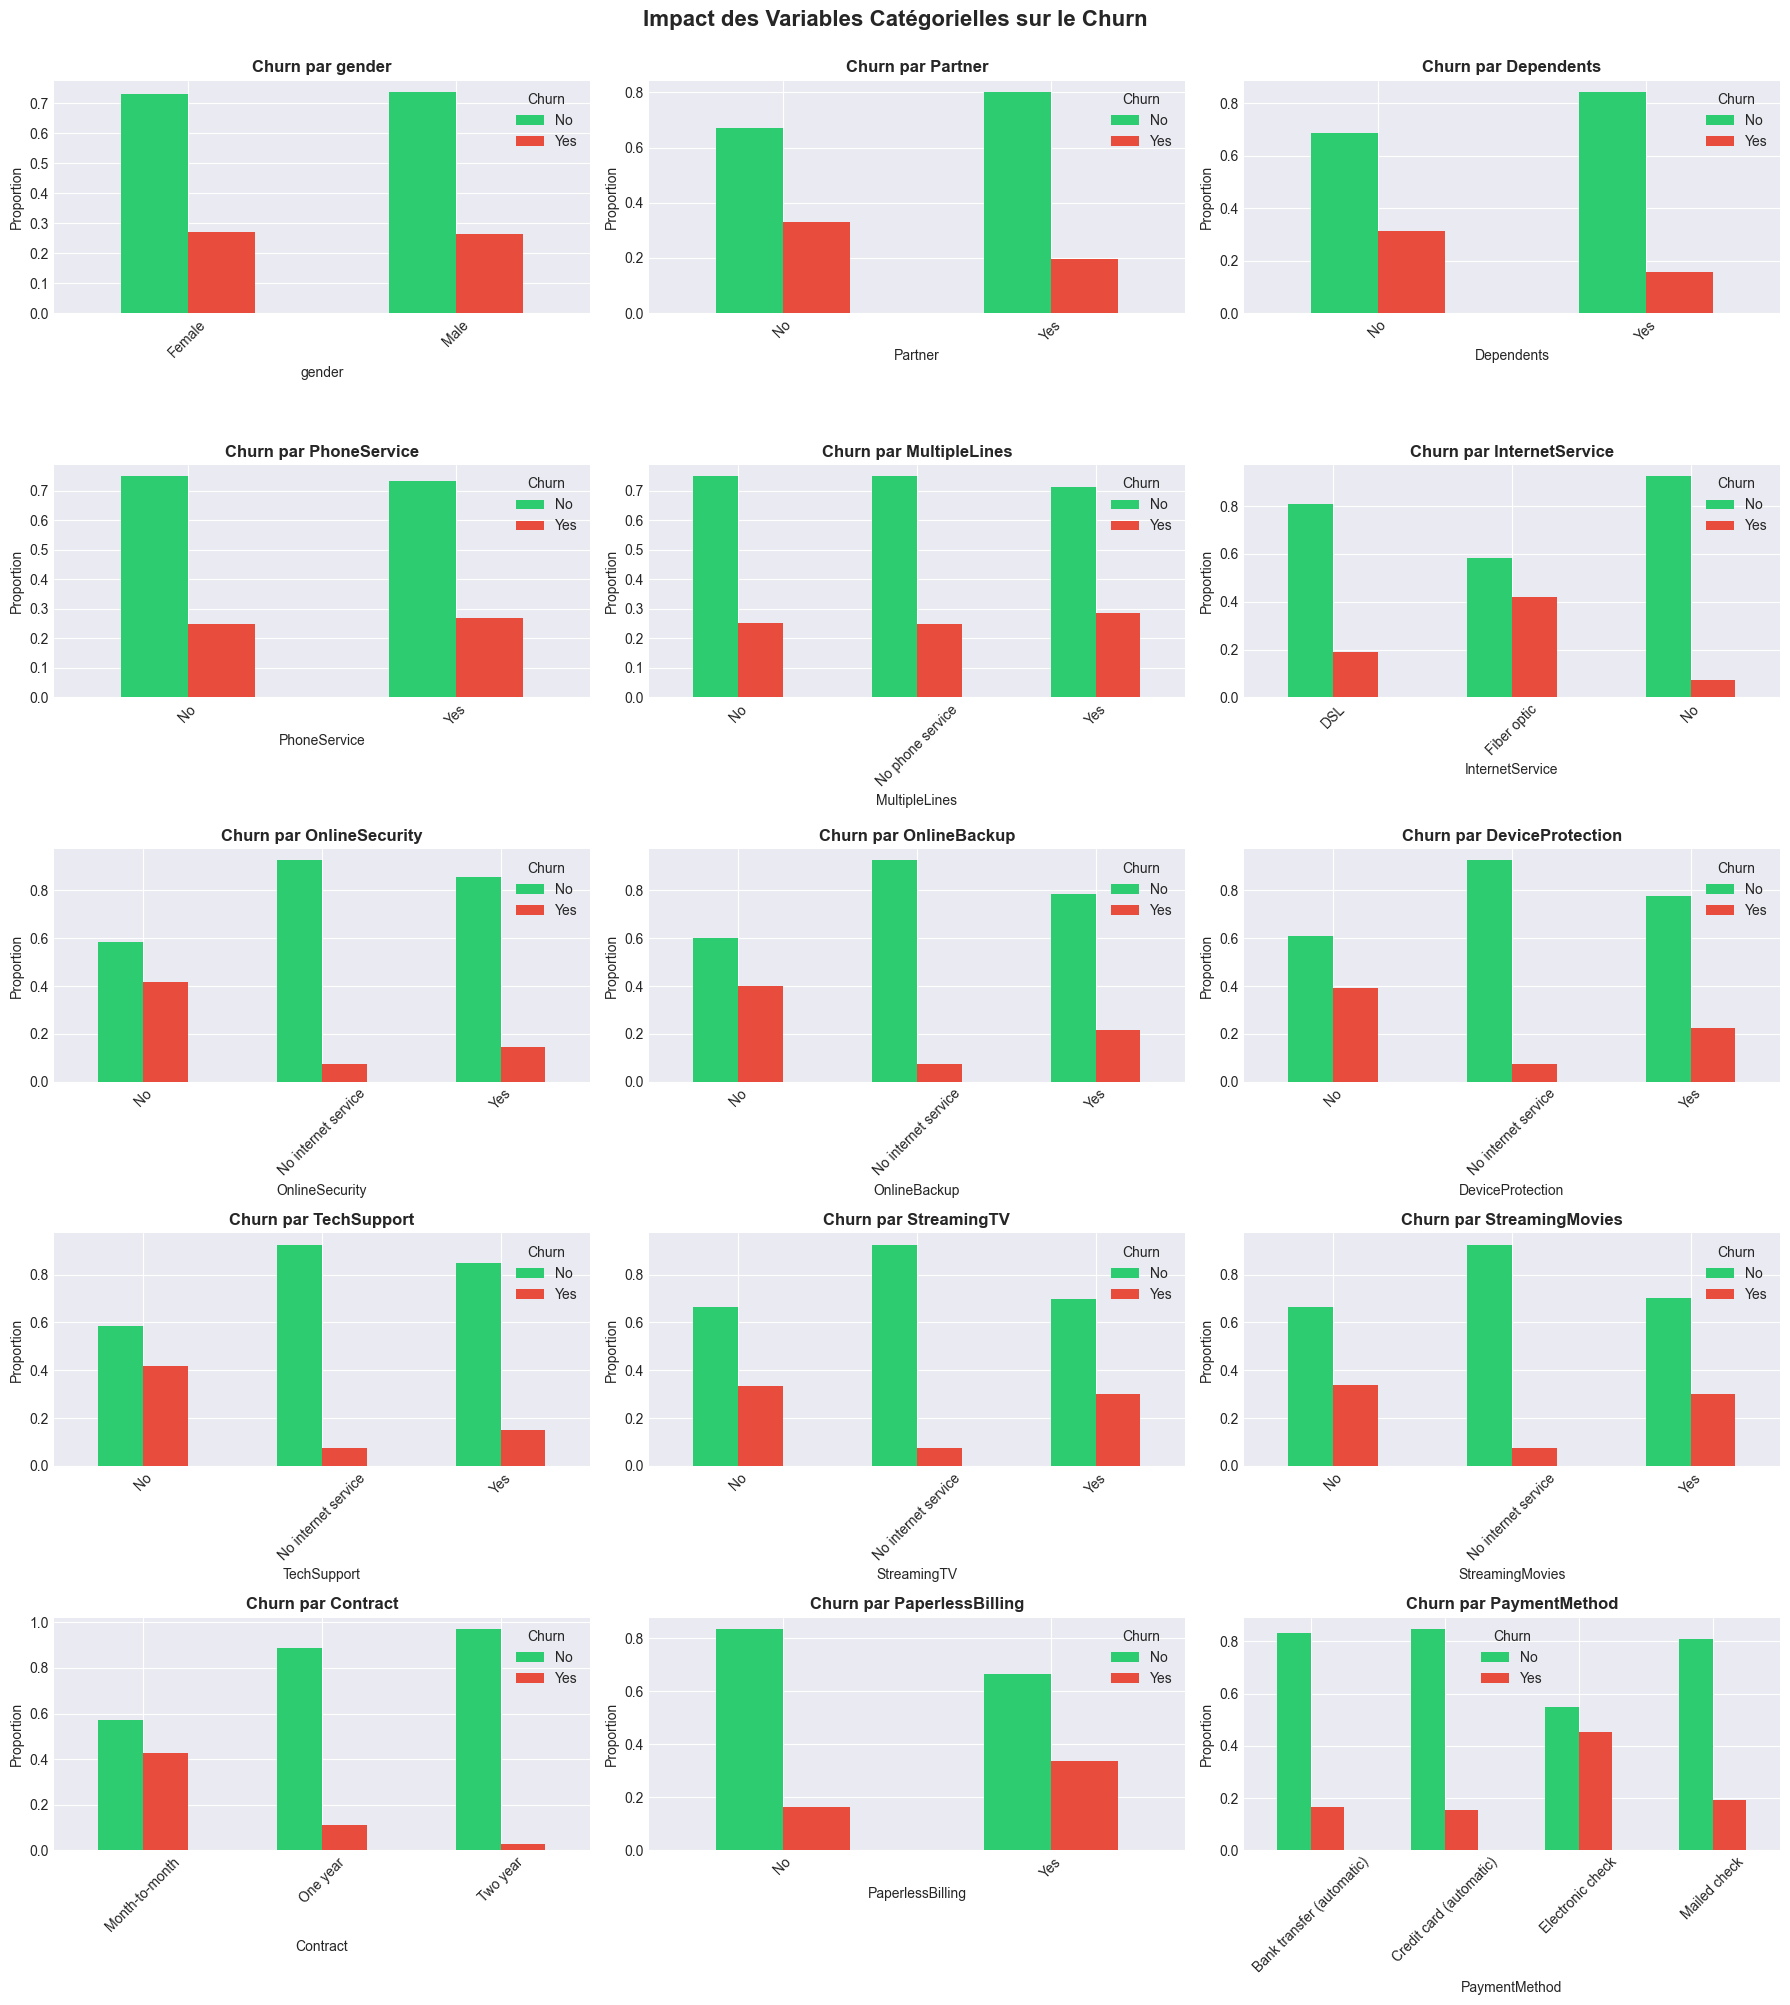

In [63]:
import math

# Pour chaque variable catégorielle, analyser le taux de churn
churn_rates = {}

for col in categorical_cols:
    # Calculer le taux de churn par catégorie
    churn_by_cat = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100)
    churn_rates[col] = churn_by_cat

# Dynamiquement déterminer le nombre de lignes et de colonnes pour les sous-graphiques
num_cols_plot = 3  # Nombre de colonnes souhaité
num_rows_plot = math.ceil(len(categorical_cols) / num_cols_plot)

fig, axes = plt.subplots(num_rows_plot, num_cols_plot, figsize=(6 * num_cols_plot, 4 * num_rows_plot))
axes = axes.flatten() if num_rows_plot > 1 or num_cols_plot > 1 else [axes]

for i, col in enumerate(categorical_cols):
    # Taux de churn par catégorie
    churn_by_cat = df.groupby(col)['Churn'].value_counts(normalize=True).unstack()
    churn_by_cat.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'Churn par {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Proportion')
    axes[i].legend(['No', 'Yes'], title='Churn')
    axes[i].tick_params(axis='x', rotation=45)

# Supprimer les axes inutilisés s'il y en a
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Impact des Variables Catégorielles sur le Churn', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [57]:
# Top 5 des variables avec le plus grand écart de churn
print("\n🔥 TOP 5 VARIABLES AVEC LE PLUS GRAND IMPACT SUR LE CHURN :")
impact_scores = {}
for col in categorical_cols:
    churn_by_cat = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100)
    impact_scores[col] = churn_by_cat.max() - churn_by_cat.min()

top_impact = sorted(impact_scores.items(), key=lambda x: x[1], reverse=True)[:5]
for i, (col, score) in enumerate(top_impact, 1):
    print(f"{i}. {col} : écart de {score:.1f}% points")



🔥 TOP 5 VARIABLES AVEC LE PLUS GRAND IMPACT SUR LE CHURN :
1. Contract : écart de 39.9% points
2. InternetService : écart de 34.5% points
3. OnlineSecurity : écart de 34.3% points
4. TechSupport : écart de 34.2% points
5. OnlineBackup : écart de 32.5% points


MATRICE DE CORRÉLATION

In [59]:
print("\n🔗 MATRICE DE CORRÉLATION DES VARIABLES NUMÉRIQUES")
print("="*80)

# Convertir Churn en numérique pour la corrélation
df_corr = df.copy()
df_corr['Churn_numeric'] = (df_corr['Churn'] == 'Yes').astype(int)

# Sélectionner uniquement les colonnes numériques
numeric_for_corr = df_corr.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Calculer la matrice de corrélation
corr_matrix = df_corr[numeric_for_corr].corr()


🔗 MATRICE DE CORRÉLATION DES VARIABLES NUMÉRIQUES


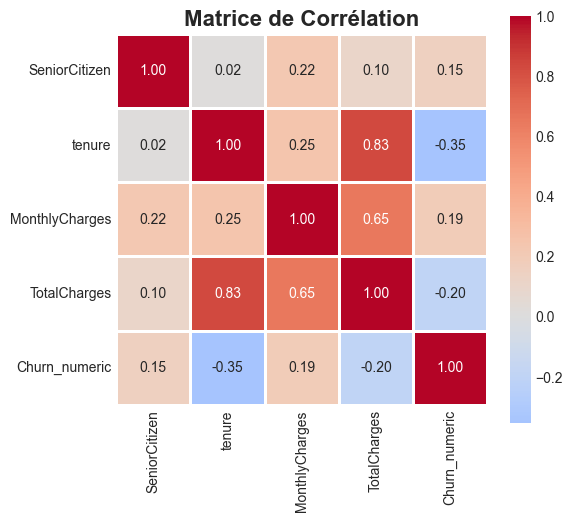


📊 CORRÉLATION AVEC LA VARIABLE CIBLE (Churn) :
MonthlyCharges    0.192858
SeniorCitizen     0.150541
TotalCharges     -0.199484
tenure           -0.354049
Name: Churn_numeric, dtype: float64

💡 INSIGHT :
   - Corrélation > 0.3 = forte corrélation positive (augmente le churn)
   - Corrélation < -0.3 = forte corrélation négative (diminue le churn)


In [62]:
# Visualisation
plt.figure(figsize=(6, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matrice de Corrélation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Variables les plus corrélées avec Churn
print("\n📊 CORRÉLATION AVEC LA VARIABLE CIBLE (Churn) :")
churn_corr = corr_matrix['Churn_numeric'].sort_values(ascending=False)
print(churn_corr[churn_corr.index != 'Churn_numeric'])

print("\n💡 INSIGHT :")
print("   - Corrélation > 0.3 = forte corrélation positive (augmente le churn)")
print("   - Corrélation < -0.3 = forte corrélation négative (diminue le churn)")


INSIGHTS ET HYPOTHÈSES

In [ ]:
print("\n🎯 SYNTHÈSE DES INSIGHTS CLÉS")
print("="*80)

print("""
1. DÉSÉQUILIBRE DES CLASSES :
   - On va travailler d'abord comme ça, j'ai pas envie d'utiliser des méthodes comme SMOTE

2. VARIABLES IMPORTANTES IDENTIFIÉES :
   - Contract, InternetService, OnlineSecurity, TechSupport, OnlineBackup en plus des variables numériques 
   - Ces variables seront cruciales pour le modèle

3. QUALITÉ DES DONNÉES :
   - On avait juste 11 valeurs manquantes sur la colonne TotalCharges qui correspondaient à la valeur 0 de tenue. On a juste supprimer ces lignes là.
   - On a laissé les outliers, ce sont pas vraiment des valeurs impossibles. 

4. CORRÉLATIONS :
   - Les variables fortement corrélées avec Churn: 
      MonthlyCharges    0.192858 
      tenure           -0.354049
   - Les variables trop corrélées entre elles (multicolinéarité):
      TotalCharges et tenure  0.85
      TotalCharges et MonthyCharges    0.65

5. HYPOTHÈSES POUR LA MODÉLISATION :
   - Les clients avec des contrats de chaque mois ont plus de churn. 
   - Les clients les plus récents ont plus de churn. 
   - Les clients avec charges totales élevées ont tendance à partir. 
""")



🎯 SYNTHÈSE DES INSIGHTS CLÉS

1. DÉSÉQUILIBRE DES CLASSES :
   - On va travailler d'abord comme ça, j'ai pas envie d'utiliser des méthodes comme SMOTE

2. VARIABLES IMPORTANTES IDENTIFIÉES :
   - Contract, InternetService, OnlineSecurity, TechSupport, OnlineBackup en plus des variables numériques 
   - Ces variables seront cruciales pour le modèle

3. QUALITÉ DES DONNÉES :
   - On avait juste 11 valeurs manquantes sur la colonne TotalCharges qui correspondaient à la valeur 0 de tenue. On a juste supprimer ces lignes là.
   - On a laissé les outliers, ce sont pas vraiment des valeurs impossibles. 

4. CORRÉLATIONS :
   - Les variables fortement corrélées avec Churn: 
      MonthlyCharges    0.192858 
      tenure           -0.354049
   - Les variables trop corrélées entre elles (multicolinéarité):
      TotalCharges et tenure  0.85
      TotalCharges et MonthyCharges    0.65

5. HYPOTHÈSES POUR LA MODÉLISATION :
   - Les clients avec des contrats de chaque mois ont plus de churn. 
   -